# All Steps of former Piepline

In [1]:
import sys
import os

# Add the project root directory to sys.path
project_root = os.path.abspath("../../")  # Adjust the relative path as needed
if project_root not in sys.path:
    sys.path.append(project_root)

## Bulk download of CRS data

In [ ]:
# Import the necessary functions from src
from src.download_crs import get_full_crs_parquet_url, download_crs_parquet

# Get the full CRS parquet URL
file_url = get_full_crs_parquet_url()

# Download the CRS data
crs = download_crs_parquet(file_url)

In [ ]:
# Save raw CRS to feather 
crs.to_feather("../../data/raw/crs_raw.feather")

17211813340

## Inspecting CRS data

In [70]:
# Load from feather
import pandas as pd

crs_raw = pd.read_feather("../../data/raw/crs_raw.feather")

In [76]:
# Alphabetically sorted columns
sorted(crs_raw.columns)

crs_raw.shape

(5811128, 98)

1973 2023


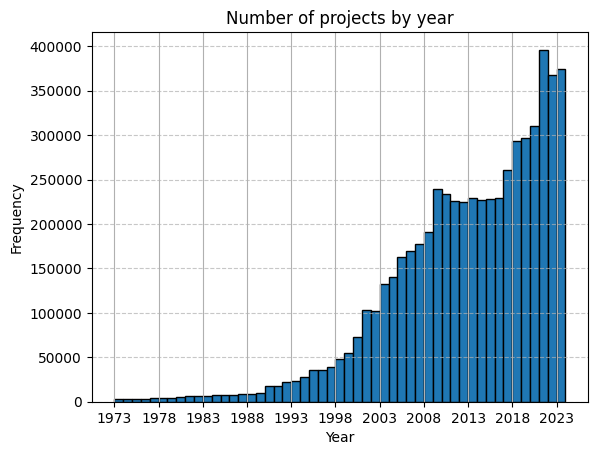

In [78]:
# Histogram of year column with bin size = 1 year
print(crs_raw['year'].min(), crs_raw['year'].max())
crs_raw['year'].hist(bins=range(crs_raw['year'].min(), crs_raw['year'].max() + 2), edgecolor='black')

import matplotlib.pyplot as plt
plt.title("Number of projects by year")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set ticks to start at the first year and end at the last year
plt.xticks(range(crs_raw['year'].min(), crs_raw['year'].max() + 1, 5))  # Adjust step size (e.g., 5) as needed
plt.show()


In [82]:
#sorted(crs_raw['purpose_code'].unique())

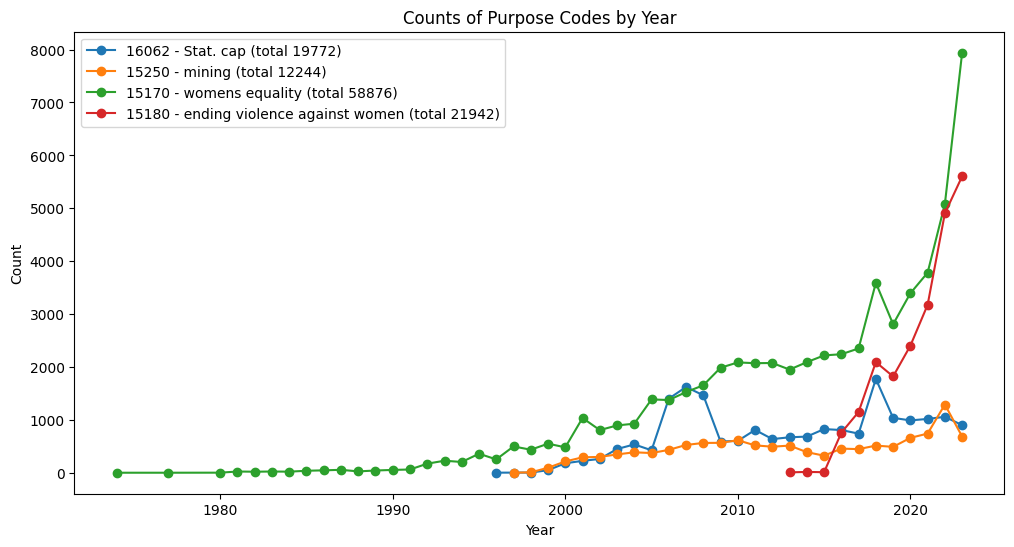

In [87]:
# Count of values in the purpose_code column for each year
counts_16062 = crs_raw[crs_raw['purpose_code'] == 16062].groupby('year')['purpose_code'].count()
counts_15250 = crs_raw[crs_raw['purpose_code'] == 15250].groupby('year')['purpose_code'].count()
counts_15170 = crs_raw[crs_raw['purpose_code'] == 15170].groupby('year')['purpose_code'].count()
counts_15180 = crs_raw[crs_raw['purpose_code'] == 15180].groupby('year')['purpose_code'].count()

# Plot the counts for all purpose codes
plt.figure(figsize=(12, 6))
plt.plot(counts_16062.index, counts_16062.values, label=f'16062 - Stat. cap (total {counts_16062.sum()})', marker='o')
plt.plot(counts_15250.index, counts_15250.values, label=f'15250 - mining (total {counts_15250.sum()})', marker='o')
plt.plot(counts_15170.index, counts_15170.values, label=f'15170 - womens equality (total {counts_15170.sum()})', marker='o')
plt.plot(counts_15180.index, counts_15180.values, label=f'15180 - ending violence against women (total {counts_15180.sum()})', marker='o')

# Add title, labels, and legend
plt.title('Counts of Purpose Codes by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend()
plt.show()

In [44]:
# Long descriptions prior to 2010 for purpose_code 16062
long_descriptions = crs[crs['year'] < 2010][crs['purpose_code'] == 16062]['long_description'].unique()

long_descriptions[10:20]

C:\Users\jojoa\AppData\Local\Temp\ipykernel_23412\256687382.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  long_descriptions = crs[crs['year'] < 2010][crs['purpose_code'] == 16062]['long_description'].unique()


array(['Appui à la Recherche Scientifique et Technique au Tchad',
       'Institutional Modernisation of The National Institute of Statistics',
       "The Integrated Early Childhood Development Project for Eritrea promotes the healthy growth and holistic development of Eritrean children. The project expands access to and improves the quality of services that address young children's basic needs. There are five project components. The first improves child health by providing on-the-job and pre-service training to health workers and caregivers, financing drugs, medical equipment, and supplies and strengthening procurement, storage, and distribution mechanisms, promoting adoption of healthy practices such as breastfeeding and the correct treatment of infections, using environmental health interventions to control childhood illnesses, and improving communications for behavioral change, The second component builds capacities for families and communities for improving the nutritional and he

In [46]:
purposecode_names = crs[['purpose_code', 'purpose_name']].drop_duplicates()

In [ ]:
print(crs.shape)

# Remove all rows with year < 2010
crs = crs[crs["year"] >= 2010]

print(crs.shape)
crs.columns

Index(['year', 'donor_code', 'de_donorcode', 'donor_name', 'agency_code',
       'agency_name', 'crs_id', 'project_number', 'initial_report',
       'recipient_code', 'de_recipientcode', 'recipient_name', 'region_code',
       'de_regioncode', 'region_name', 'incomegroup_code',
       'de_incomegroup_code', 'incomegroup_name', 'flow_code', 'flow_name',
       'bi_multi', 'category', 'finance_t', 'aid_t', 'usd_commitment',
       'usd_disbursement', 'usd_received', 'usd_commitment_defl',
       'usd_disbursement_defl', 'usd_received_defl', 'usd_adjustment',
       'usd_adjustment_defl', 'usd_amount_untied', 'usd_amount_partial_tied',
       'usd_amount_tied', 'usd_amount_untied_defl',
       'usd_amount_partial_tied_defl', 'usd_amounttied_defl', 'usd_irtc',
       'usd_expert_commitment', 'usd_expert_extended', 'usd_export_credit',
       'currency_code', 'commitment_national', 'disbursement_national',
       'grant_equiv', 'usd_grant_equiv', 'short_description', 'project_title',
      

In [ ]:
# Inspect encoding for long description of rows that are not None
crs["long_description"].dropna()

count    3.444865e+06
mean     3.990502e+02
std      6.579111e+02
min      1.000000e+00
25%      5.600000e+01
50%      1.430000e+02
75%      4.000000e+02
max      4.160000e+03
Name: long_description, dtype: float64

In [ ]:
# Summary statistics for long description with number of na values
print(crs["long_description"].isna().sum())
print(crs["long_description"].describe())

# Mean length of long descriptions
crs["long_description"].str.len().mean()

455615
count                      3444865
unique                      991090
top       TC AGGREGATED ACTIVITIES
freq                        146722
Name: long_description, dtype: object


np.float64(396.2042701237929)

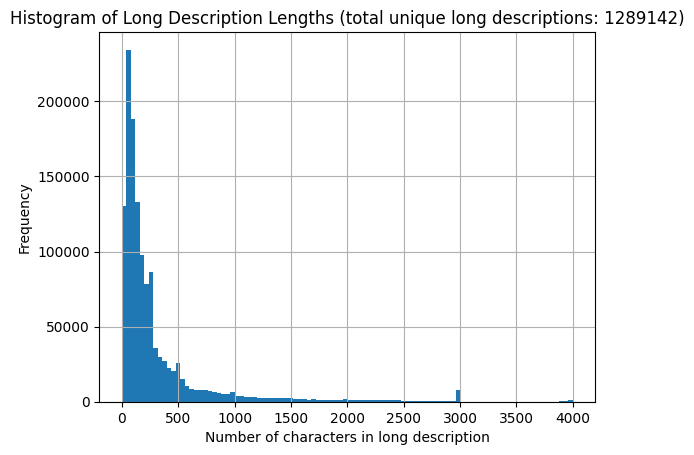

In [12]:
import matplotlib.pyplot as plt 
# Histogram of long description lengths
pd.Series(crs["long_description"].unique()).str.len().hist(bins=100)

plt.title(f"Histogram of Long Description Lengths (total unique long descriptions: {crs['long_description'].nunique()})")
plt.xlabel("Number of characters in long description")
plt.ylabel("Frequency")
plt.show()


In [17]:
import os 
import pandas as pd

# Save first 100 non-na long descriptions to csv in folder data/development/
if not os.path.exists("../../data/development/"):
    os.makedirs("../../data/development/")

# Convert the unique values to a pandas DataFrame and save to CSV
pd.DataFrame(crs["long_description"].dropna().unique()[:100], columns=["long_description"]).to_csv(
    "../../data/development/crs_test_long_description.csv", index=False
)

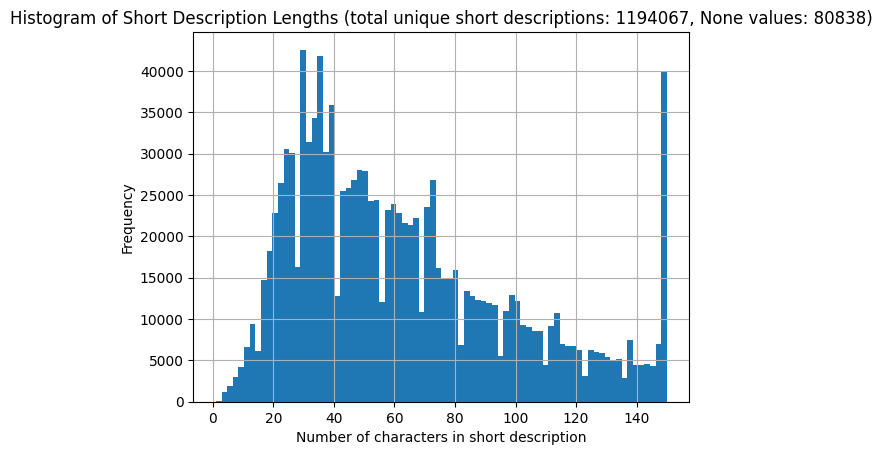

In [ ]:
# Make a histogram of the unique short_description lengths and include the number of None values
pd.Series(crs["short_description"].unique()).str.len().hist(bins=80)

import matplotlib.pyplot as plt
plt.title(f"Histogram of Short Description Lengths (total unique short descriptions: {crs['short_description'].nunique()}, None values: {crs['short_description'].isna().sum()})")
plt.xlabel("Number of characters in short description")
plt.ylabel("Frequency")
plt.show()

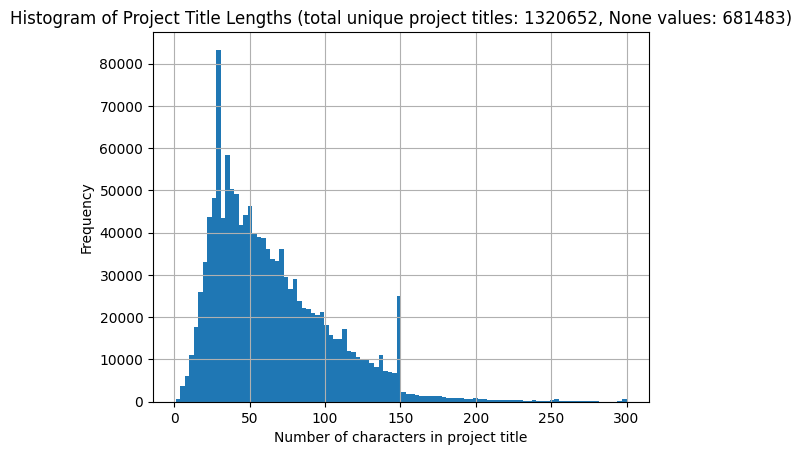

In [14]:
# Make a histogram of the unique prject_title lengths and include the number of None values
pd.Series(crs["project_title"].unique()).str.len().hist(bins=100)

import matplotlib.pyplot as plt
plt.title(f"Histogram of Project Title Lengths (total unique project titles: {crs['project_title'].nunique()}, None values: {crs['project_title'].isna().sum()})")
plt.xlabel("Number of characters in project title")
plt.ylabel("Frequency")
plt.show()

## Title keyword matching & add statistis purpose code marker

In [20]:
# Needed to download spacy models first - execute in terminal
# python -m nltk.downloader wordnet
# python -m spacy download en_core_web_sm
# python -m spacy download fr_core_news_sm
# python -m spacy download es_core_news_sm
# python -m spacy download de_core_news_sm

In [138]:
import fasttext
from langdetect import detect
import os 
import spacy
import re
from nltk.stem import WordNetLemmatizer
from rapidfuzz import fuzz, process

# Load spaCy models
spacy_models = {
    'en': spacy.load('en_core_web_sm'),
    'fr': spacy.load('fr_core_news_sm'),
    'es': spacy.load('es_core_news_sm'),
    'de': spacy.load('de_core_news_sm'),
    # Add more languages if needed
}

# Normalize text
def normalize(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

# Detect language using langdetect
def detect_language_langdetect(text):
    try:
        lang_code = detect(text)
        return lang_code
    except Exception as e:
        print(f"Error detecting language: {e}")
        return None

# Load the fasttext language detection model
fasttext_model = fasttext.load_model("./models/lid.176.bin")  # Adjust the path to your model file

# Detect language using fasttext
def detect_language_fasttext(text):
    try:
        # Predict the language using fasttext
        predictions = fasttext_model.predict(text, k=1)  # Get the top-1 prediction
        lang_code = predictions[0][0].replace("__label__", "")  # Extract the language code
        return lang_code
    except Exception as e:
        print(f"Error detecting language: {e}")
        return None

# Lemmatize using spaCy
def lemmatize(text, lang):
    if lang in spacy_models:
        doc = spacy_models[lang](text)
        
        return [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    else:
        return text.split()  # fallback

# Load keywords from .txt files
def load_keywords():
    keywords = {}
    for lang in ['en', 'es', 'fr', 'de']:
        file_name = f"../../data/keywords/final/statistics_reduced_{lang}_final.txt"
        if os.path.exists(file_name):
            with open(file_name, 'r', encoding='utf-8') as f:
                keywords[lang] = [line.strip() for line in f.readlines()]
        else:
            keywords[lang] = []
    return keywords

def lemmatized_phrase_match(text, keywords, lang, threshold=85):
    # Use the lemmatize function to process the text
    lemmatized_text = " ".join(lemmatize(text, lang))

    matches = []

    # Return empty list if language is not one of the supported languages
    if lang not in keywords:
        return matches

    for phrase in keywords[lang]:
        # Lemmatize the keyword phrase using the lemmatize function
        lemmatized_phrase = " ".join(lemmatize(phrase, lang))

        # Fuzzy match between lemmatized text and lemmatized keyword phrase
        score = fuzz.partial_ratio(lemmatized_phrase, lemmatized_text)
        if score >= threshold:
            matches.append(phrase)

    return matches


# Function to process a single row
def process_title(title, keywords):
    
    if pd.isna(title):
        return pd.Series({
            'language': None,
            'matched_keywords': []
        })
    else:
        try:
            norm_text = normalize(title)
            lang = detect_language_fasttext(norm_text)
            matched_keywords = lemmatized_phrase_match(norm_text, keywords, lang)

            return pd.Series({
                'language': lang,
                'matched_keywords': matched_keywords
            })
        except Exception as e:
            print(f"Error processing title: {e}")
            return pd.Series({
                'language': None,
                'matched_keywords': []
            })

In [3]:
title = crs['project_title'].dropna().unique()[100]

detect_language_fasttext(title)

'en'

In [23]:
keywords = load_keywords()  

print(keywords['en'][:10])

# Lemmatize keywords for each language in dictionary
for lang, words in keywords.items():
    keywords[lang] = [' '.join(lemmatize(word, lang)) for word in words]

['statistics', 'survey', 'census', 'database', 'big data', 'data for decisions', 'civil registr', 'land registr', 'cadaster', 'sdg indicator']


In [32]:
title = crs['project_title'].dropna().unique()[55]
keywords = load_keywords()  
print(f"Title: {title}")
print(f"Language langdetec: {detect_language_langdetect(normalize(title))}")
lang_detected = detect_language_langdetect(normalize(title))
print(f"Language fasttext: {lang_detected}")
print(f"Normalized: {normalize(title)}")
print(f"Normalized & lemmatized: {lemmatize(normalize(title), lang_detected)}")
print(f"Lemmatized: {lemmatize(title, lang_detected)}")
print(f"Matched Keywords: {lemmatized_phrase_match(normalize(title), keywords, lang_detected, threshold=85)}")

Title: WID QUARTERLY NEWSLETTER (POF
Language langdetec: en
Language fasttext: en
Normalized: wid quarterly newsletter pof
Normalized & lemmatized: ['wid', 'quarterly', 'newsletter', 'pof']
Lemmatized: ['WID', 'QUARTERLY', 'newsletter', 'POF']
Matched Keywords: []


In [27]:
# Apply process row function to the first 100 rows of the dataframe
crs_test = crs.head(10000).copy()

# Reduce crs_test to only the columns we need
crs_test = crs_test[['project_title', 'short_description', 'long_description']]

# Print the number of na values in the project_title column
print(crs_test['project_title'].isna().sum())

keywords = load_keywords()  

crs_test['language'] = None
crs_test['matched_keywords'] = None

#import swifter
# Apply the process_title function to the 'project_title' column
crs_test[['language', 'matched_keywords']] = crs_test['project_title'].apply(lambda title: process_title(title, keywords))

3964


KeyboardInterrupt: 

In [8]:
# Make new column for title_stat_match if matched_keywords is not empty
crs_test['title_stat_match'] = crs_test['matched_keywords'].apply(lambda x: len(x) > 0)

In [10]:
print(crs_test.columns)

Index(['year', 'donor_code', 'de_donorcode', 'donor_name', 'agency_code',
       'agency_name', 'crs_id', 'project_number', 'initial_report',
       'recipient_code',
       ...
       'usd_arrears_interest', 'capital_expend', 'ps_iflag', 'ps_iflag_name',
       'psi_add_type', 'psi_add_desc', 'psi_add_dev_obj', 'language',
       'matched_keywords', 'title_stat_match'],
      dtype='object', length=101)


### Try vectorized operations



In [141]:
import pandas as pd
import numpy as np
import os
import re
from rapidfuzz import fuzz, process
import spacy
import fasttext

# Load spaCy models
spacy_models = {
    'en': spacy.load('en_core_web_sm'),
    'fr': spacy.load('fr_core_news_sm'),
    'es': spacy.load('es_core_news_sm'),
    'de': spacy.load('de_core_news_sm'),
}

# Load the fasttext language detection model
fasttext_model = fasttext.load_model("./models/lid.176.bin")  # Adjust the path to your model file

# Normalize text
def normalize_series(text_series):
    return text_series.str.lower().str.replace(r'[^\w\s]', '', regex=True).str.strip()

# Normalize text in a list
def normalize_list(text_list):
    return [re.sub(r'[^\w\s]', '', text.lower()).strip() for text in text_list]

# Detect language using fasttext (vectorized)
def detect_language_fasttext_series(text_series):
    def detect_language(text):
        try:
            predictions = fasttext_model.predict(text, k=1)
            return predictions[0][0].replace("__label__", "")
        except Exception:
            return None
    return text_series.apply(detect_language)

def lemmatize(text, lang):
    if lang in spacy_models:
        doc = spacy_models[lang](text)
        lemmatized = [token.lemma_ if token.lemma_ else token.text for token in doc if token.is_alpha]
        if not lemmatized:  # If lemmatization fails, fallback
            return text.split("-")
        return lemmatized
    else:
        return text.split()  # fallback

# Lemmatize using spaCy (vectorized)
def lemmatize_series(text_series, lang_series):
    return pd.Series(np.vectorize(lemmatize)(text_series, lang_series))

# Load keywords from .txt files
def load_keywords():
    keywords = {}
    for lang in ['en', 'es', 'fr', 'de']:
        file_name = f"../../data/keywords/final/statistics_reduced_{lang}_final.txt"
        if os.path.exists(file_name):
            with open(file_name, 'r', encoding='utf-8') as f:
                keywords[lang] = [line.strip() for line in f.readlines() if line.strip()]
        else:
            keywords[lang] = []
    return keywords

from rapidfuzz import process, utils

# Vectorized match_keywords function
def match_keywords(text_series, lang_series, keywords_dict):
    """
    Matches exact keywords in the text by joining lemmas and detecting keywords in the joined text lemmas.
    
    Args:
        text_series (pd.Series): Series of normalized and lemmatized text.
        lang_series (pd.Series): Series of detected languages corresponding to the text.
        keywords_dict (dict): Dictionary of keywords for each language.

    Returns:
        pd.Series: Series of lists containing matched keywords for each text.
    """
    def detect_keywords(text, lang):
        if lang not in keywords_dict or pd.isna(text):
            return []
        # Join keywords for the given language
        keyword_phrases = keywords_dict[lang]
        # Detect keywords in the text
        return [kw for kw in keyword_phrases if kw in text]

    # Apply the detection function vectorized over the text and language series
    return pd.Series(np.vectorize(detect_keywords)(text_series, lang_series))

def detect_keywords(text, lang, keywords_dict):
    if lang not in keywords_dict or pd.isna(text):
        return None
    # Join keywords for the given language
    keyword_phrases = keywords_dict[lang]
    # Detect keywords in the text
    matches = [kw for kw in keyword_phrases if kw in text]
    if matches:
        return matches
    else:
        return None

# Optimized match_keywords function with lemmatization
def fuzzy_match_keywords(lemmatized_text, lang, lemmatized_keywords, threshold=85):
    """
    Match lemmatized keyword phrases using RapidFuzz with preprocessing and score_cutoff optimization.
    """
    if lang not in lemmatized_keywords or not lemmatized_text:
        return None

    # Preprocess and lemmatize the input text
    #lemmatized_text = " ".join(text)
    
    # Preprocess and lemmatize the keywords for the given language
    #lemmatized_keywords = [" ".join(keyword) for keyword in keywords[lang]]

    # Use RapidFuzz's extract function with score_cutoff to optimize matching
    matches = process.extractOne(
        lemmatized_text,
        lemmatized_keywords[lang],
        processor=None,  # Preprocessed already
        score_cutoff=threshold
    )

    # Return the original keywords that matched
    if matches: 
        return [lemmatized_keywords[lang][matches[2]]]
    else:
        return None

# Process titles (vectorized)
def process_titles(df, keywords):
    df['normalized_title'] = normalize_series(df['project_title'])
    df['language'] = detect_language_fasttext_series(df['normalized_title'])
    df['matched_keywords'] = match_keywords(df['normalized_title'], df['language'], keywords)
    df['title_stat_match'] = df['matched_keywords'].apply(lambda x: len(x) > 0)
    return df


In [15]:
keywords = load_keywords()
crs_test = crs.head(10000).copy()
crs_test = crs_test[['project_title', 'short_description', 'long_description']]

In [16]:
# Process titles (vectorized)
crs_test['normalized_title'] = normalize_series(crs_test['project_title'])

In [17]:
crs_test['language'] = detect_language_fasttext_series(crs_test['normalized_title'])

In [ ]:
crs_test['matched_keywords'] = crs_test.apply(lambda row: detect_keywords(row['normalized_title'], row['language'], keywords), axis=1)

In [95]:
import pandas as pd
import time
from tqdm import tqdm
import swifter

# Enable tqdm for pandas
#tqdm.pandas()

print(crs_test['normalized_title'][0])

# Apply the match_keywords function to each row in the DataFrame
crs_test['matched_keywords'] = crs_test.swifter.apply(lambda row: match_keywords(row['normalized_title'], row['language'], keywords, threshold=89), axis =1)

None


Pandas Apply:   0%|          | 0/10000 [00:00<?, ?it/s]

#### Test for full crs

In [147]:
import pandas as pd
import time
from tqdm import tqdm
import swifter

keywords = load_keywords()

# Lemmatize keywords for each language in dictionary
for lang, words in keywords.items():
    keywords[lang] = [' '.join(lemmatize(word, lang)) for word in words]
    keywords[lang] = normalize_list(keywords[lang])

In [148]:
crs = crs[['project_title', 'short_description', 'long_description']]
crs['normalized_title'] = normalize_series(crs['project_title'])
crs['language'] = detect_language_fasttext_series(crs['normalized_title'])

C:\Users\jojoa\AppData\Local\Temp\ipykernel_3436\3303592232.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crs['normalized_title'] = normalize_series(crs['project_title'])
C:\Users\jojoa\AppData\Local\Temp\ipykernel_3436\3303592232.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crs['language'] = detect_language_fasttext_series(crs['normalized_title'])


In [149]:
crs['matched_keywords'] = crs.apply(lambda row: detect_keywords(row['normalized_title'], row['language'], keywords), axis=1)

In [150]:
# Save the processed crs description data frame in the development folder as feather 
crs.to_feather("../../data/development/crs_lang_stat_detected.feather")

In [ ]:
#crs_test = crs[20000:40000].copy()
crs_positive = crs[crs['matched_keywords'].notna()]

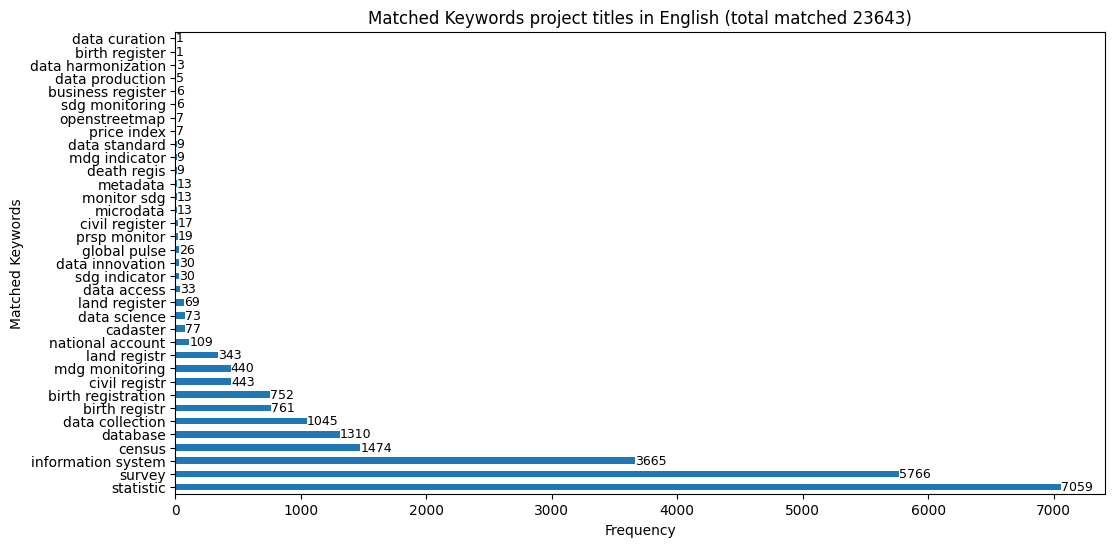

In [163]:
# Filter for English projects
english_keywords = crs_positive[crs_positive['language'] == 'en']['matched_keywords'].explode().value_counts()

# Plot the bar chart
ax = english_keywords.plot(kind='barh', figsize=(12, 6))
plt.title(f"Matched Keywords project titles in English (total matched {english_keywords.sum()})")
plt.xlabel("Frequency")
plt.ylabel("Matched Keywords")

# Add frequency values to the right of each bar
for i, v in enumerate(english_keywords):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)

plt.show()


### Make basic statistics from detected languages and keywords 

In [29]:
crs['language'].value_counts()

language
en     4234264
fr      606074
es      102472
de       47690
it       21614
        ...   
mwl          1
bpy          1
hif          1
sah          1
bcl          1
Name: count, Length: 144, dtype: int64

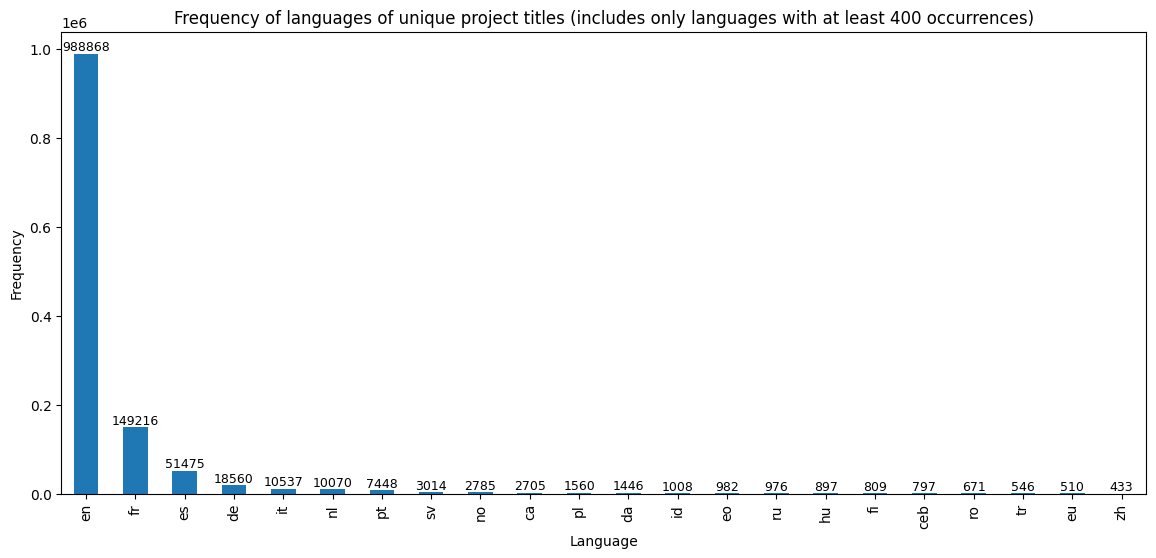

In [ ]:
import matplotlib.pyplot as plt

# Filter languages with at least 100 occurrences
language_counts = crs[['normalized_title', 'language']].drop_duplicates()['language'].value_counts()
filtered_language_counts = language_counts[language_counts >= 400]

# Create the figure and plot the bar chart
plt.figure(figsize=(14, 6))
ax = filtered_language_counts.plot(kind='bar')
plt.title("Frequency of languages of unique project titles (includes only languages with at least 400 occurrences)") 
plt.xlabel("Language")
plt.ylabel("Frequency")
plt.xticks(rotation=90)

# Add the actual frequency of each language above the bars
for index, value in enumerate(filtered_language_counts):
    plt.text(index, value + 500, str(value), ha='center', va='bottom', fontsize=9)

plt.show()



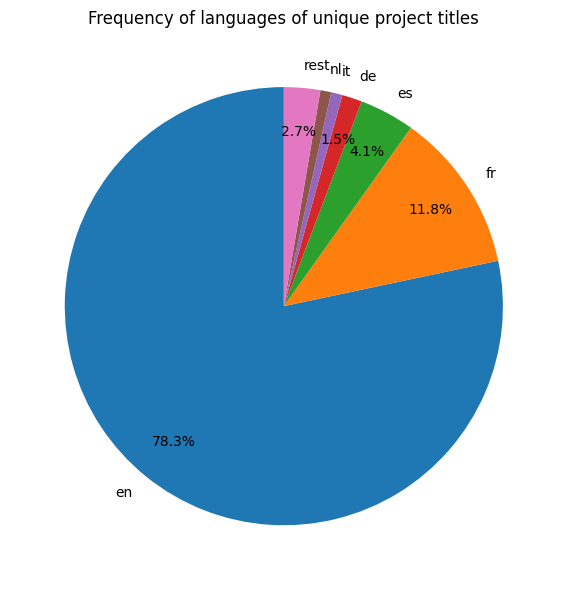

In [69]:
# Make a pie chart of the languages for frequencies > 1000, and summarize them as rest in the pie chart 
language_counts = crs[['normalized_title', 'language']].drop_duplicates()['language'].value_counts()
filtered_language_counts['rest'] = language_counts[language_counts < 10000].sum()

# Create the figure and plot the pie chart
plt.figure(figsize=(6, 6))
ax = filtered_language_counts.plot(
    kind='pie', 
    autopct=lambda p: '{:.1f}%'.format(p) if p > 1 else '',  # Show percentages only if > 5%
    startangle=90, 
    legend=False, 
    pctdistance=0.8  # Adjust the distance of the percentage labels
)
plt.title("Frequency of languages of unique project titles")
plt.ylabel('')  # Hide the y-label
plt.tight_layout()  # Adjust layout to prevent overlap
